# Notebook 02: KPI Analysis & Revenue Insights — HealthFirst Australia

**Project:** HealthFirst Australia — Revenue Intelligence Platform  
**Purpose:** Calculate core clinical and financial KPIs, perform root-cause analysis of the Month 7 revenue drop, and surface actionable insights for the executive team.  
**Author:** Analytics Team  
**Date:** 2026-04-12

---

### KPI Catalogue

| # | KPI | Chart |
|---|-----|-------|
| 1 | Monthly revenue trend (by billing type) | Stacked area chart |
| 2 | Bulk billing rate by month | Line chart |
| 3 | Average wait time by specialty | Horizontal bar chart |
| 4 | No-show rate by month | Line chart |
| 5 | Patient satisfaction trend | Line chart |
| 6 | Revenue per appointment by specialty (margin) | Grouped bar chart |
| RCA | Root cause analysis — Month 7 drop | Waterfall chart |
| — | Patient churn by state | Horizontal bar chart |

In [2]:
# ── Imports & global settings ──────────────────────────────────────────────────
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')

CLEAN_DIR   = '../data/cleaned/'
REPORTS_DIR = '../reports/'
os.makedirs(REPORTS_DIR, exist_ok=True)

print('Environment ready.')

Environment ready.


---
## 1. Load Cleaned Data

In [4]:
# ── Load all five cleaned datasets ────────────────────────────────────────────
patients     = pd.read_csv(CLEAN_DIR + 'patients.csv')
appointments = pd.read_csv(CLEAN_DIR + 'appointments.csv',
                           parse_dates=['appointment_date'])
staff        = pd.read_csv(CLEAN_DIR + 'staff.csv')
surveys      = pd.read_csv(CLEAN_DIR + 'satisfaction_surveys.csv',
                           parse_dates=['survey_date'])
billing      = pd.read_csv(CLEAN_DIR + 'billing_claims.csv')

for name, df in [('patients', patients), ('appointments', appointments),
                  ('staff', staff), ('surveys', surveys), ('billing', billing)]:
    print(f'  {name:>15s}  →  {df.shape[0]:>7,} rows  ×  {df.shape[1]:>2} cols')

         patients  →    3,000 rows  ×  20 cols
     appointments  →   20,000 rows  ×  16 cols
            staff  →       80 rows  ×  11 cols
          surveys  →    3,894 rows  ×  12 cols
          billing  →   11,094 rows  ×  10 cols


In [5]:
# ── Add month and month_num helper columns to appointments ─────────────────────
appointments['month'] = appointments['appointment_date'].dt.to_period('M')

min_year  = appointments['appointment_date'].dt.year.min()
min_month = appointments.loc[
    appointments['appointment_date'].dt.year == min_year,
    'appointment_date'
].dt.month.min()

appointments['month_num'] = (
    (appointments['appointment_date'].dt.year - min_year) * 12
    + appointments['appointment_date'].dt.month
    - min_month
    + 1
)

print(f'Month range: {appointments["month"].min()}  →  {appointments["month"].max()}')
print(f'month_num  : {appointments["month_num"].min()}  →  {appointments["month_num"].max()}')
print()
print('Billing type distribution:')
print(appointments['billing_type'].value_counts().to_string())

Month range: 2024-01  →  2025-12
month_num  : 1  →  24

Billing type distribution:
billing_type
bulk_bill      7639
self_pay       5690
gap_payment    3903
private        2768


---
## KPI 1 — Monthly Revenue Trend by Billing Type

In [7]:
# ── Filter to completed appointments only for revenue analysis ─────────────────
completed = appointments[appointments['status'] == 'completed'].copy()

# Pivot: billed_amount by month × billing_type
rev_by_type = (
    completed
    .groupby(['month', 'billing_type'])['billed_amount']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

# Canonical column order
billing_cols = ['bulk_bill', 'gap_payment', 'private', 'self_pay']
billing_cols = [c for c in billing_cols if c in rev_by_type.columns]

rev_by_type = rev_by_type.sort_values('month')
months_str  = rev_by_type['month'].astype(str)

print('Monthly revenue by billing type ($):')
print(rev_by_type[['month'] + billing_cols].head(6).to_string(index=False))

Monthly revenue by billing type ($):
  month  bulk_bill  gap_payment   private  self_pay
2024-01  15,317.45    24,024.07 14,289.80 15,827.65
2024-02  16,218.70    25,899.11 13,671.32 12,394.98
2024-03  16,109.00    18,999.22 18,064.79 17,128.82
2024-04  17,552.80    24,712.25 14,297.70 19,119.45
2024-05  18,144.25    20,167.09 16,144.59 18,482.02
2024-06  16,849.20    18,664.13 13,005.40 15,907.06


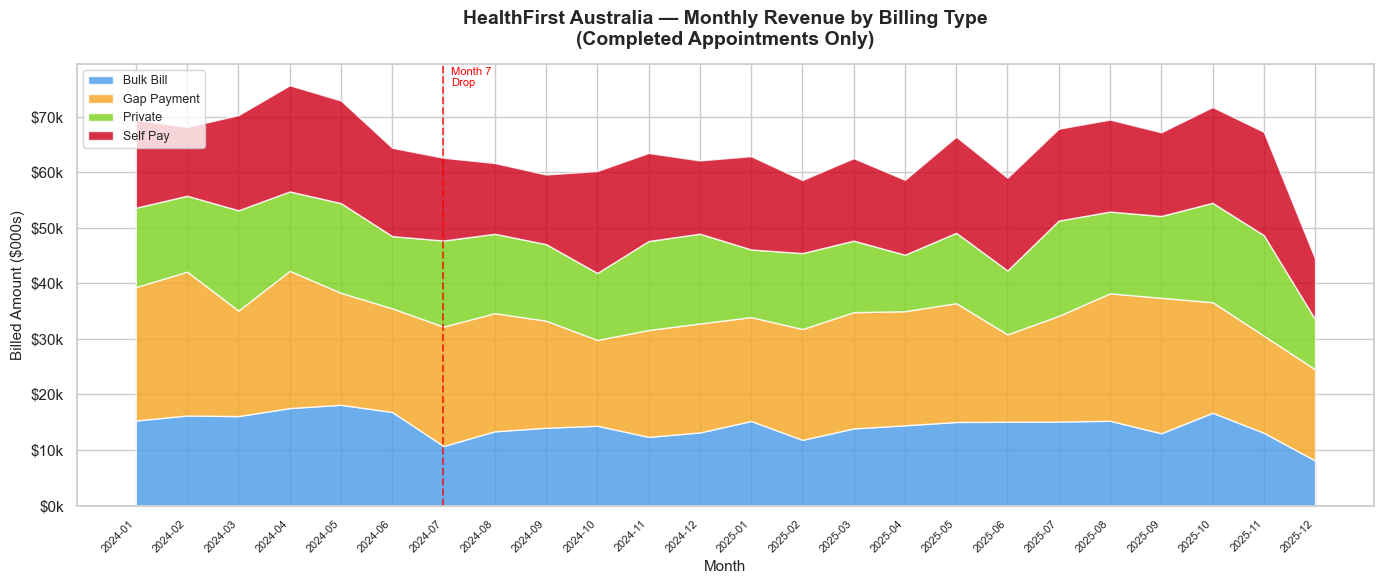

Saved → /Users/sahana/Documents/revenue-intelligence/reports/revenue_trend.png


In [8]:
# ── Stacked area chart — revenue by billing type ──────────────────────────────
PALETTE = {
    'bulk_bill'  : '#4C9BE8',
    'gap_payment': '#F5A623',
    'private'    : '#7ED321',
    'self_pay'   : '#D0021B',
}

fig, ax = plt.subplots(figsize=(14, 6))

ys = [rev_by_type[c].values / 1000 for c in billing_cols]
colors = [PALETTE.get(c, '#999') for c in billing_cols]
labels = [c.replace('_', ' ').title() for c in billing_cols]

ax.stackplot(range(len(months_str)), ys, labels=labels, colors=colors, alpha=0.82)

ax.set_title(
    'HealthFirst Australia — Monthly Revenue by Billing Type\n(Completed Appointments Only)',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Billed Amount ($000s)', fontsize=11)
ax.set_xticks(range(len(months_str)))
ax.set_xticklabels(months_str, rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}k'))
ax.legend(loc='upper left', fontsize=9)

# Mark month 7
ax.axvline(x=6, color='red', linestyle='--', alpha=0.7, linewidth=1.4, label='Month 7')
ax.text(6.15, ax.get_ylim()[1] * 0.95, 'Month 7\nDrop', color='red', fontsize=8)

plt.tight_layout()
out = REPORTS_DIR + 'revenue_trend.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {os.path.abspath(out)}')

---
## KPI 2 — Bulk Billing Rate by Month

In [10]:
# ── Bulk billing rate: bulk_bill / all completed appointments ─────────────────
bulk_trend = (
    completed
    .groupby('month_num')
    .apply(lambda d: pd.Series({
        'total_appts'     : len(d),
        'bulk_bill_appts' : (d['billing_type'] == 'bulk_bill').sum(),
    }))
    .reset_index()
)
bulk_trend['bulk_bill_rate'] = (
    bulk_trend['bulk_bill_appts'] / bulk_trend['total_appts'] * 100
).round(2)

print('Bulk billing rate by month:')
print(bulk_trend[['month_num', 'total_appts', 'bulk_bill_appts', 'bulk_bill_rate']]
      .to_string(index=False))

Bulk billing rate by month:
 month_num  total_appts  bulk_bill_appts  bulk_bill_rate
         1          503              201           39.96
         2          488              197           40.37
         3          527              214           40.61
         4          535              211           39.44
         5          535              221           41.31
         6          502              217           43.23
         7          427              133           31.15
         8          443              164           37.02
         9          405              162           40.00
        10          477              173           36.27
        11          438              152           34.70
        12          435              172           39.54
        13          469              185           39.45
        14          408              147           36.03
        15          461              178           38.61
        16          437              178           40.73
   

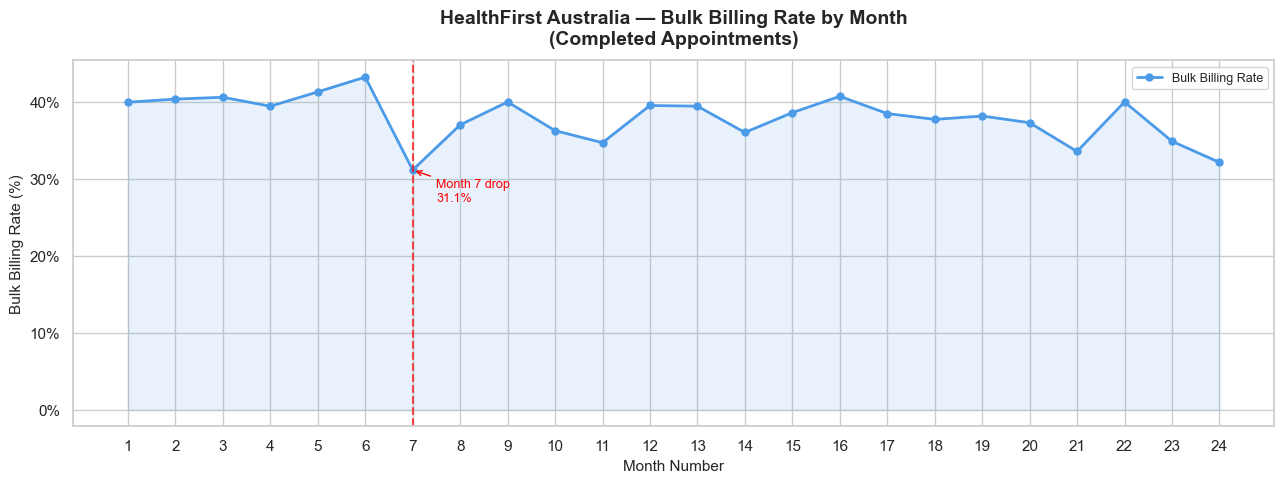

Saved → /Users/sahana/Documents/revenue-intelligence/reports/bulk_billing_trend.png


In [11]:
# ── Line chart with Month 7 annotation ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    bulk_trend['month_num'], bulk_trend['bulk_bill_rate'],
    marker='o', linewidth=2, color='#4C9BE8', markersize=5, label='Bulk Billing Rate'
)

# Shade the area under the curve
ax.fill_between(
    bulk_trend['month_num'], bulk_trend['bulk_bill_rate'],
    alpha=0.12, color='#4C9BE8'
)

# Mark month 7 drop
if 7 in bulk_trend['month_num'].values:
    m7_rate = float(bulk_trend.loc[bulk_trend['month_num'] == 7, 'bulk_bill_rate'].iloc[0])
    ax.axvline(x=7, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.annotate(
        f'Month 7 drop\n{m7_rate:.1f}%',
        xy=(7, m7_rate), xytext=(7.5, m7_rate - 4),
        arrowprops=dict(arrowstyle='->', color='red'),
        fontsize=9, color='red'
    )

ax.set_title(
    'HealthFirst Australia — Bulk Billing Rate by Month\n(Completed Appointments)',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Month Number', fontsize=11)
ax.set_ylabel('Bulk Billing Rate (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_xticks(bulk_trend['month_num'])
ax.legend(fontsize=9)

plt.tight_layout()
out = REPORTS_DIR + 'bulk_billing_trend.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {os.path.abspath(out)}')

---
## KPI 3 — Average Wait Time by Specialty

In [13]:
# ── Average wait_days by specialty (all statuses included) ────────────────────
wait_by_spec = (
    appointments
    .groupby('specialty')['wait_days']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_wait', 'median': 'median_wait', 'count': 'n_appts'})
    .sort_values('avg_wait', ascending=True)
    .reset_index()
)

print('Average wait days by specialty:')
print(wait_by_spec.to_string(index=False))

Average wait days by specialty:
    specialty  avg_wait  median_wait  n_appts
    Emergency      7.49         7.00     1984
           GP     13.57        13.00     8089
  Paediatrics     19.53        20.00     1585
  Dermatology     19.63        19.00     2383
 Orthopaedics     27.34        28.00     1195
     Oncology     27.35        27.00      856
   Cardiology     27.36        27.00     1573
Mental Health     53.17        51.00     2335


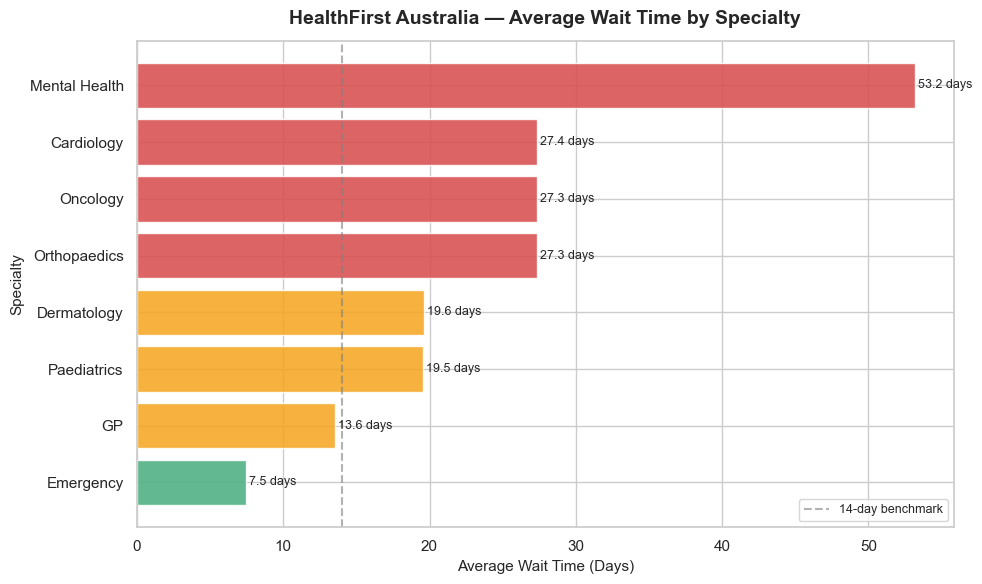

Saved → /Users/sahana/Documents/revenue-intelligence/reports/wait_times.png


In [14]:
# ── Horizontal bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = [
    '#D94F4F' if v > 20 else '#F5A623' if v > 12 else '#4CAF82'
    for v in wait_by_spec['avg_wait']
]

bars = ax.barh(
    wait_by_spec['specialty'], wait_by_spec['avg_wait'],
    color=bar_colors, alpha=0.88, edgecolor='white'
)

for bar, val in zip(bars, wait_by_spec['avg_wait']):
    ax.text(
        bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
        f'{val:.1f} days', va='center', fontsize=9
    )

ax.axvline(x=14, color='gray', linestyle='--', alpha=0.6,
           label='14-day benchmark')

ax.set_title(
    'HealthFirst Australia — Average Wait Time by Specialty',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Average Wait Time (Days)', fontsize=11)
ax.set_ylabel('Specialty', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
out = REPORTS_DIR + 'wait_times.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {os.path.abspath(out)}')

---
## KPI 4 — No-Show Rate by Month

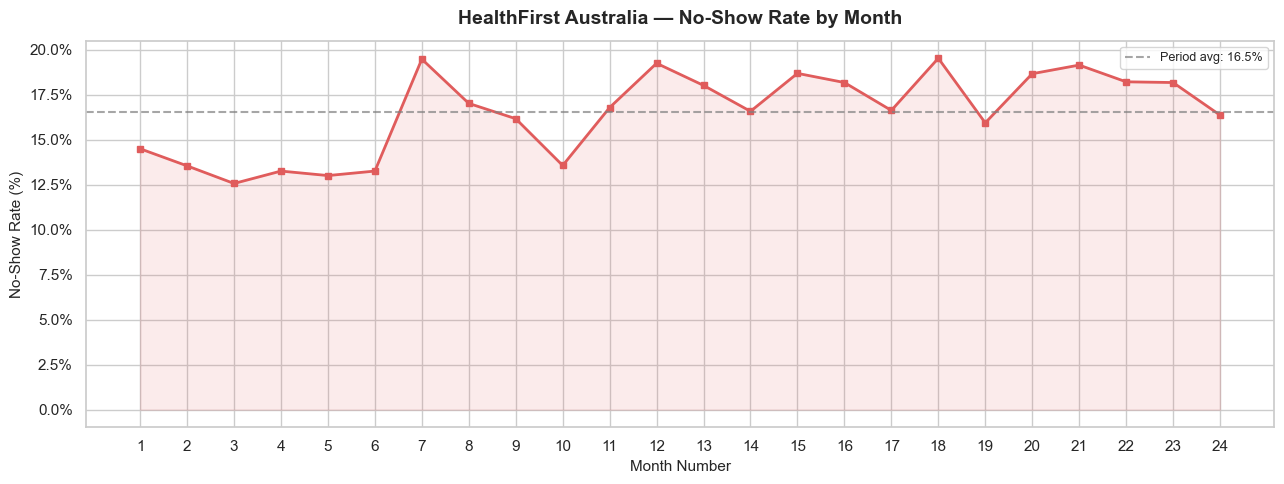

Saved → /Users/sahana/Documents/revenue-intelligence/reports/noshow_trend.png


In [16]:
# ── No-show rate = no_show / (completed + no_show + cancelled) by month ────────
noshow_trend = (
    appointments
    .groupby('month_num')
    .apply(lambda d: pd.Series({
        'total'   : len(d),
        'no_show' : (d['status'] == 'no_show').sum(),
    }))
    .reset_index()
)
noshow_trend['noshow_rate'] = (
    noshow_trend['no_show'] / noshow_trend['total'] * 100
).round(2)

# ── Line chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    noshow_trend['month_num'], noshow_trend['noshow_rate'],
    marker='s', linewidth=2, color='#E05C5C', markersize=5
)
ax.fill_between(
    noshow_trend['month_num'], noshow_trend['noshow_rate'],
    alpha=0.12, color='#E05C5C'
)
ax.axhline(
    noshow_trend['noshow_rate'].mean(), color='gray',
    linestyle='--', alpha=0.7,
    label=f'Period avg: {noshow_trend["noshow_rate"].mean():.1f}%'
)

ax.set_title(
    'HealthFirst Australia — No-Show Rate by Month',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Month Number', fontsize=11)
ax.set_ylabel('No-Show Rate (%)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}%'))
ax.set_xticks(noshow_trend['month_num'])
ax.legend(fontsize=9)

plt.tight_layout()
out = REPORTS_DIR + 'noshow_trend.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {os.path.abspath(out)}')

---
## KPI 5 — Patient Satisfaction Trend by Month

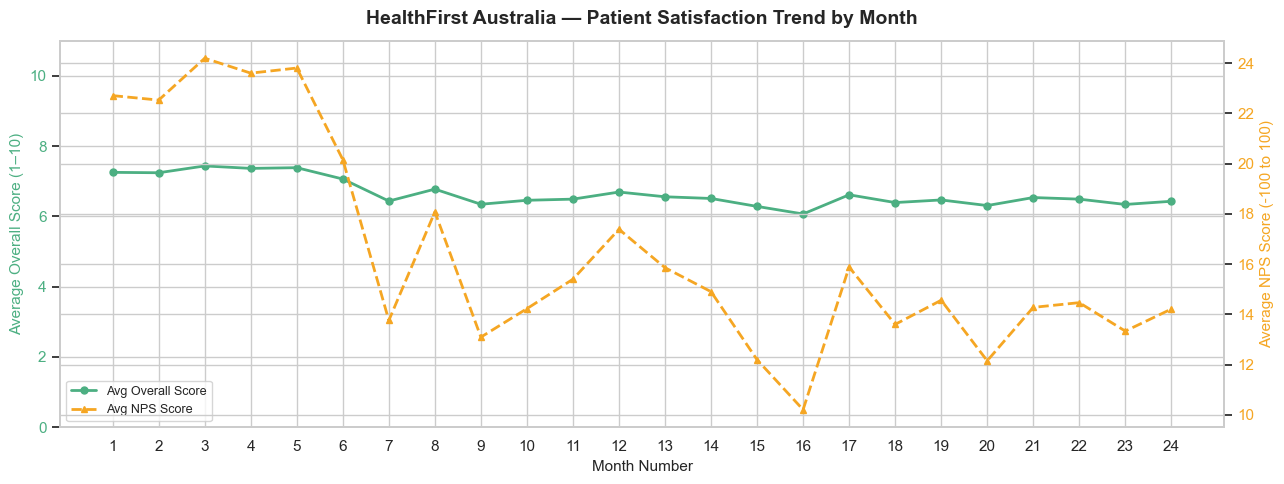

Saved → /Users/sahana/Documents/revenue-intelligence/reports/satisfaction_trend.png


In [18]:
# ── Join surveys to appointments to get month_num ──────────────────────────────
surveys_with_month = surveys.merge(
    appointments[['appointment_id', 'month_num']].drop_duplicates('appointment_id'),
    on='appointment_id', how='left'
)

sat_trend = (
    surveys_with_month
    .dropna(subset=['month_num'])
    .groupby('month_num')
    .agg(
        avg_score  = ('overall_score', 'mean'),
        n_surveys  = ('survey_id', 'count'),
        avg_nps    = ('nps_score', 'mean'),
    )
    .reset_index()
)

# ── Line chart ────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))

color_score = '#4CAF82'
color_nps   = '#F5A623'

ax1.plot(
    sat_trend['month_num'], sat_trend['avg_score'],
    marker='o', linewidth=2, color=color_score, markersize=5, label='Avg Overall Score'
)
ax1.set_ylabel('Average Overall Score (1–10)', fontsize=11, color=color_score)
ax1.tick_params(axis='y', labelcolor=color_score)
ax1.set_ylim(0, 11)

ax2 = ax1.twinx()
ax2.plot(
    sat_trend['month_num'], sat_trend['avg_nps'],
    marker='^', linewidth=2, color=color_nps,
    linestyle='--', markersize=5, label='Avg NPS Score'
)
ax2.set_ylabel('Average NPS Score (-100 to 100)', fontsize=11, color=color_nps)
ax2.tick_params(axis='y', labelcolor=color_nps)

ax1.set_title(
    'HealthFirst Australia — Patient Satisfaction Trend by Month',
    fontsize=14, fontweight='bold', pad=12
)
ax1.set_xlabel('Month Number', fontsize=11)
ax1.set_xticks(sat_trend['month_num'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower left')

plt.tight_layout()
out = REPORTS_DIR + 'satisfaction_trend.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {os.path.abspath(out)}')

---
## KPI 6 — Revenue per Appointment by Specialty (Margin)

In [20]:
# ── Average billed_amount vs staff_cost by specialty ─────────────────────────
spec_rev = (
    completed
    .groupby('specialty')
    .agg(
        avg_billed = ('billed_amount', 'mean'),
        avg_cost   = ('staff_cost',    'mean'),
        n_appts    = ('appointment_id', 'count'),
    )
    .reset_index()
)
spec_rev['avg_margin'] = spec_rev['avg_billed'] - spec_rev['avg_cost']
spec_rev['margin_pct'] = (spec_rev['avg_margin'] / spec_rev['avg_billed'] * 100).round(1)
spec_rev = spec_rev.sort_values('avg_billed', ascending=False)

print('Revenue per appointment by specialty:')
print(spec_rev[['specialty', 'avg_billed', 'avg_cost', 'avg_margin', 'margin_pct', 'n_appts']]
      .to_string(index=False))

Revenue per appointment by specialty:
    specialty  avg_billed  avg_cost  avg_margin  margin_pct  n_appts
     Oncology      334.52     79.76      254.76       76.20      494
 Orthopaedics      300.26     75.32      224.95       74.90      648
   Cardiology      256.12     65.00      191.12       74.60      860
Mental Health      184.00     54.99      129.01       70.10     1325
  Dermatology      173.73     45.17      128.55       74.00     1311
  Paediatrics      129.55     34.86       94.69       73.10      886
    Emergency       96.11     30.04       66.07       68.70     1114
           GP       61.42     17.99       43.43       70.70     4456


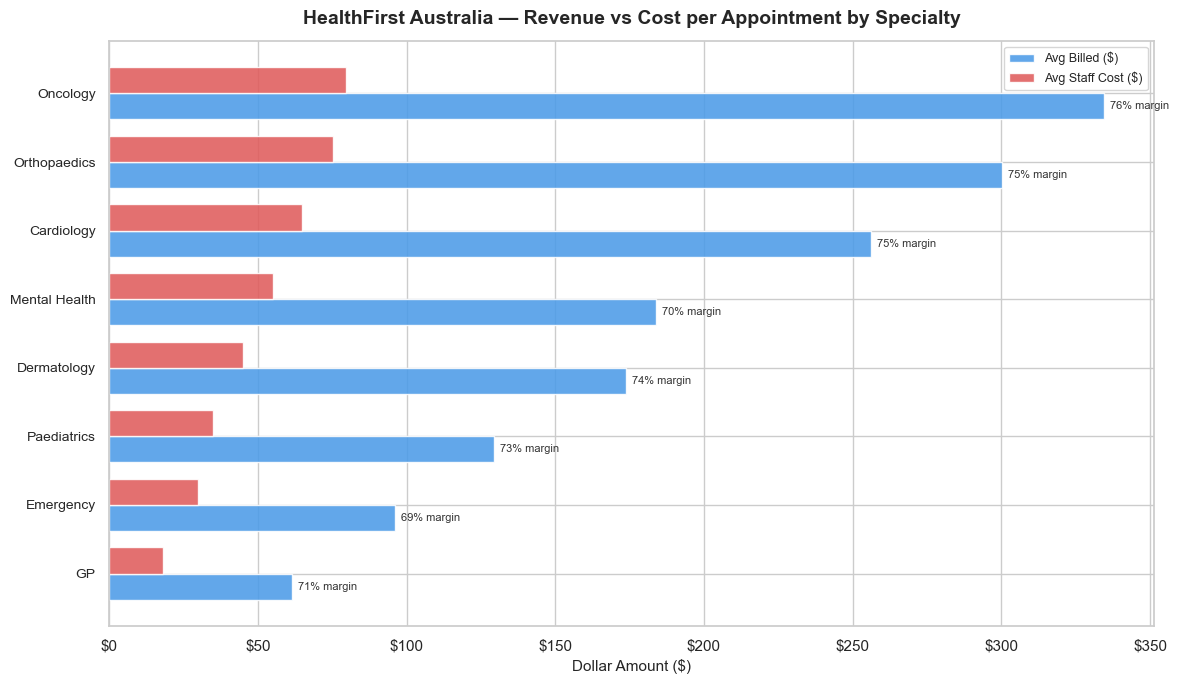

Saved → /Users/sahana/Documents/revenue-intelligence/reports/specialty_revenue.png


In [21]:
# ── Grouped bar chart: avg billed vs avg cost per specialty ───────────────────
spec_sorted = spec_rev.sort_values('avg_billed', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

y      = np.arange(len(spec_sorted))
height = 0.38

bars_b = ax.barh(
    y - height / 2, spec_sorted['avg_billed'], height,
    label='Avg Billed ($)', color='#4C9BE8', alpha=0.88, edgecolor='white'
)
bars_c = ax.barh(
    y + height / 2, spec_sorted['avg_cost'], height,
    label='Avg Staff Cost ($)', color='#E05C5C', alpha=0.88, edgecolor='white'
)

# Annotate margin %
for i, row in spec_sorted.reset_index(drop=True).iterrows():
    ax.text(
        row['avg_billed'] + 2, i - height / 2,
        f"{row['margin_pct']:.0f}% margin",
        va='center', fontsize=8, color='#333'
    )

ax.set_yticks(y)
ax.set_yticklabels(spec_sorted['specialty'], fontsize=10)
ax.set_title(
    'HealthFirst Australia — Revenue vs Cost per Appointment by Specialty',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Dollar Amount ($)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=9)

plt.tight_layout()
out = REPORTS_DIR + 'specialty_revenue.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {os.path.abspath(out)}')

---
## Root Cause Analysis — Month 7 Revenue Drop

We decompose the Month 6 → Month 7 revenue change into three effects:

- **Volume effect**: fewer appointments × Month 6 average billed  
- **Rate effect**: bulk billing rate shift (lower-revenue billing mix) × Month 7 volume  
- **Mix / residual**: remaining unexplained delta (specialty mix, AOV drift within billing type)  

In [23]:
# ── Month 6 vs Month 7 summary comparison ─────────────────────────────────────
def month_stats(month_n):
    df = completed[completed['month_num'] == month_n]
    all_df = appointments[appointments['month_num'] == month_n]
    return {
        'total_appts'      : len(all_df),
        'completed_appts'  : len(df),
        'total_revenue'    : df['billed_amount'].sum(),
        'avg_billed'       : df['billed_amount'].mean() if len(df) > 0 else 0,
        'bulk_bill_rate'   : (all_df['billing_type'] == 'bulk_bill').mean() * 100,
        'noshow_rate'      : (all_df['status'] == 'no_show').mean() * 100,
        'avg_wait_days'    : all_df['wait_days'].mean(),
    }

m6 = month_stats(6)
m7 = month_stats(7)

comparison = pd.DataFrame({'Month 6': m6, 'Month 7': m7})
comparison['Delta'] = comparison['Month 7'] - comparison['Month 6']
comparison['Delta%'] = (comparison['Delta'] / comparison['Month 6'].abs() * 100).round(1)

print('=== MONTH 6 vs MONTH 7 COMPARISON ===')
print(comparison.to_string())

=== MONTH 6 vs MONTH 7 COMPARISON ===
                  Month 6   Month 7     Delta  Delta%
total_appts        920.00    775.00   -145.00  -15.80
completed_appts    502.00    427.00    -75.00  -14.90
total_revenue   64,425.79 62,634.28 -1,791.51   -2.80
avg_billed         128.34    146.68     18.35   14.30
bulk_bill_rate      41.63     33.29     -8.34  -20.00
noshow_rate         13.26     19.48      6.22   46.90
avg_wait_days       20.41     20.67      0.26    1.30


In [24]:
# ── Decomposition: Volume + Rate + Mix effects ─────────────────────────────────
m6_rev     = m6['total_revenue']
m7_rev     = m7['total_revenue']
rev_delta  = m7_rev - m6_rev

# Volume effect: if appointment count had changed but per-appt revenue stayed at M6 level
m6_avg = m6['avg_billed']
m7_vol = m7['completed_appts']
m6_vol = m6['completed_appts']
volume_effect = (m7_vol - m6_vol) * m6_avg

# Rate effect: bulk-billing rate change -> bulk_bill yields less revenue per appt than private.
# We approximate the revenue differential between billing types from the data.
avg_by_billing = (
    completed[completed['month_num'].isin([6, 7])]
    .groupby('billing_type')['billed_amount'].mean()
)
bulk_avg    = avg_by_billing.get('bulk_bill', 0)
private_avg = avg_by_billing.get('private', avg_by_billing.get('gap_payment', bulk_avg))
rate_delta  = (m7['bulk_bill_rate'] - m6['bulk_bill_rate']) / 100  # fractional change
# Rough revenue impact: rate shift × vol × (bulk avg - non-bulk avg)
rate_effect = rate_delta * m7_vol * (bulk_avg - private_avg)

# Mix / residual
mix_effect  = rev_delta - volume_effect - rate_effect

decomp = pd.DataFrame([
    {'Effect': 'Month 6 Revenue (baseline)', 'Amount ($)': m6_rev},
    {'Effect': 'Volume Effect (fewer completed appts)', 'Amount ($)': volume_effect},
    {'Effect': 'Bulk Billing Rate Shift', 'Amount ($)': rate_effect},
    {'Effect': 'Mix / AOV Residual', 'Amount ($)': mix_effect},
    {'Effect': 'Month 7 Revenue (actual)', 'Amount ($)': m7_rev},
])

print('=== MONTH 7 REVENUE DROP — DECOMPOSITION TABLE ===')
print(decomp.to_string(index=False))
print(f'\nTotal Revenue Delta: ${rev_delta:,.0f}  ({rev_delta / m6_rev * 100:.1f}%)')

=== MONTH 7 REVENUE DROP — DECOMPOSITION TABLE ===
                               Effect  Amount ($)
           Month 6 Revenue (baseline)   64,425.79
Volume Effect (fewer completed appts)   -9,625.37
              Bulk Billing Rate Shift    4,605.09
                   Mix / AOV Residual    3,228.77
             Month 7 Revenue (actual)   62,634.28

Total Revenue Delta: $-1,792  (-2.8%)


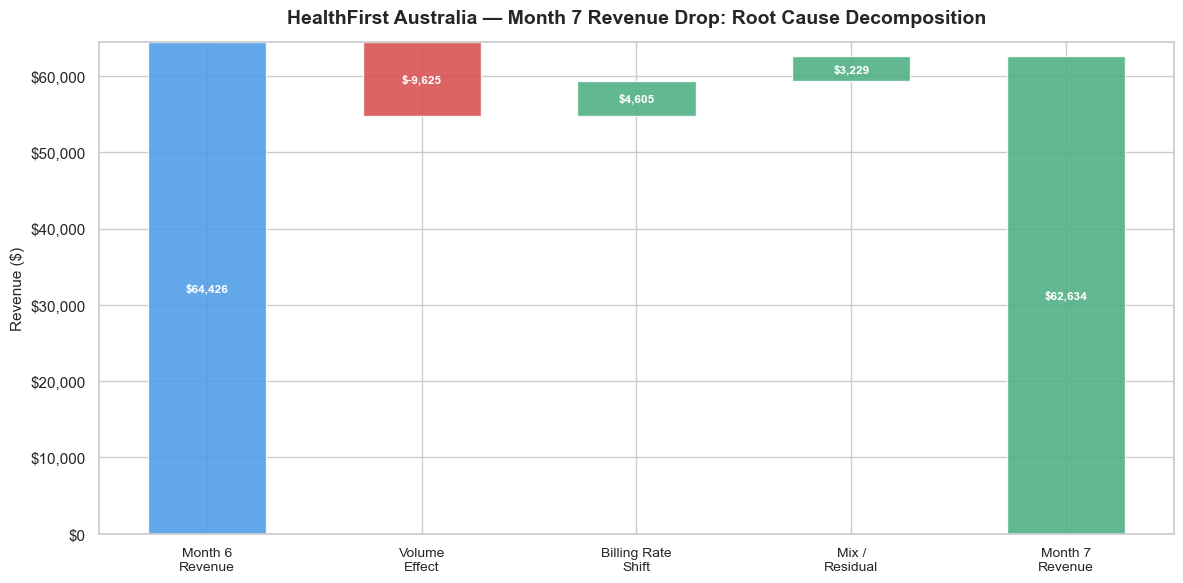

Saved → /Users/sahana/Documents/revenue-intelligence/reports/rca_waterfall.png


In [25]:
# ── Waterfall chart of revenue drop decomposition ─────────────────────────────
wf_labels   = [
    'Month 6\nRevenue',
    'Volume\nEffect',
    'Billing Rate\nShift',
    'Mix /\nResidual',
    'Month 7\nRevenue',
]
wf_values   = [m6_rev, volume_effect, rate_effect, mix_effect, m7_rev]
wf_bottoms  = [
    0,
    m6_rev,
    m6_rev + volume_effect,
    m6_rev + volume_effect + rate_effect,
    0,
]
wf_colors   = [
    '#4C9BE8',
    '#D94F4F' if volume_effect < 0 else '#4CAF82',
    '#D94F4F' if rate_effect   < 0 else '#4CAF82',
    '#D94F4F' if mix_effect    < 0 else '#4CAF82',
    '#4CAF82' if m7_rev > 0 else '#D94F4F',
]

fig, ax = plt.subplots(figsize=(12, 6))

for i, (label, val, bot, col) in enumerate(
    zip(wf_labels, wf_values, wf_bottoms, wf_colors)
):
    if label in ('Month 6\nRevenue', 'Month 7\nRevenue'):
        ax.bar(i, val, color=col, alpha=0.88, edgecolor='white', width=0.55)
        label_y = val / 2
    else:
        ax.bar(i, val, bottom=bot, color=col, alpha=0.88, edgecolor='white', width=0.55)
        label_y = bot + val / 2

    ax.text(
        i, label_y,
        f'${val:,.0f}',
        ha='center', va='center', fontsize=8.5,
        color='white', fontweight='bold'
    )

ax.set_xticks(range(len(wf_labels)))
ax.set_xticklabels(wf_labels, fontsize=10)
ax.set_title(
    'HealthFirst Australia — Month 7 Revenue Drop: Root Cause Decomposition',
    fontsize=14, fontweight='bold', pad=14
)
ax.set_ylabel('Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.axhline(0, color='black', linewidth=0.7)

plt.tight_layout()
out = REPORTS_DIR + 'rca_waterfall.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {os.path.abspath(out)}')

---
## Patient Churn by State

In [27]:
# ── Churn rate by Australian state ────────────────────────────────────────────
churn_by_state = (
    patients
    .groupby('state')
    .agg(
        total_patients  = ('patient_id', 'count'),
        churned         = ('churn_flag', 'sum'),
    )
    .reset_index()
)
churn_by_state['churn_rate'] = (
    churn_by_state['churned'] / churn_by_state['total_patients'] * 100
).round(1)
churn_by_state = churn_by_state.sort_values('churn_rate', ascending=True)

print('Patient churn by state:')
print(churn_by_state.to_string(index=False))

Patient churn by state:
state  total_patients  churned  churn_rate
   WA             277       53       19.10
  NSW             980      191       19.50
  QLD             594      120       20.20
  VIC             767      158       20.60
   SA             214       45       21.00
  ACT              66       18       27.30
  TAS              69       19       27.50
   NT              33       12       36.40


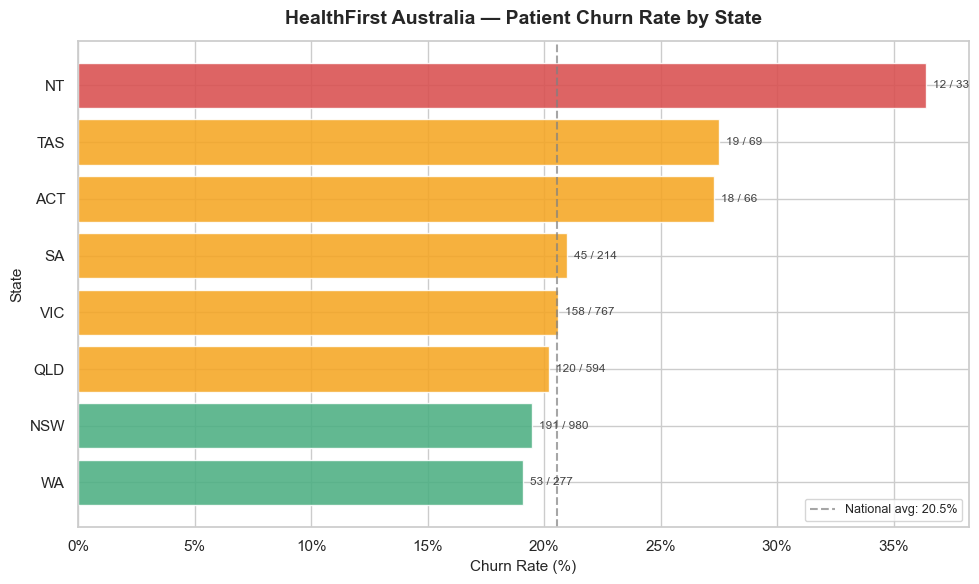

Saved → /Users/sahana/Documents/revenue-intelligence/reports/churn_by_state.png


In [28]:
# ── Horizontal bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = [
    '#D94F4F' if r > 30 else '#F5A623' if r > 20 else '#4CAF82'
    for r in churn_by_state['churn_rate']
]

bars = ax.barh(
    churn_by_state['state'], churn_by_state['churn_rate'],
    color=bar_colors, alpha=0.88, edgecolor='white'
)

for bar, n, total in zip(
    bars, churn_by_state['churned'], churn_by_state['total_patients']
):
    ax.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        f'{int(n):,} / {int(total):,}', va='center', fontsize=8.5, color='#444'
    )

overall_churn = patients['churn_flag'].mean() * 100
ax.axvline(
    overall_churn, color='gray', linestyle='--', alpha=0.7,
    label=f'National avg: {overall_churn:.1f}%'
)

ax.set_title(
    'HealthFirst Australia — Patient Churn Rate by State',
    fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Churn Rate (%)', fontsize=11)
ax.set_ylabel('State', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(fontsize=9)

plt.tight_layout()
out = REPORTS_DIR + 'churn_by_state.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {os.path.abspath(out)}')

---
## Executive Summary

In [30]:
# ── Print executive summary with key numbers ──────────────────────────────────
total_revenue        = completed['billed_amount'].sum()
total_completed      = len(completed)
total_appointments   = len(appointments)
avg_billed_appt      = completed['billed_amount'].mean()
avg_wait             = appointments['wait_days'].mean()
bulk_rate_overall    = (appointments['billing_type'] == 'bulk_bill').mean() * 100
noshow_rate_overall  = (appointments['status'] == 'no_show').mean() * 100
avg_satisfaction     = surveys['overall_score'].mean()
overall_churn_rate   = patients['churn_flag'].mean() * 100
n_invalid_medicare   = int(patients['invalid_medicare_flag'].sum()) if 'invalid_medicare_flag' in patients.columns else 'N/A'

# Month 7 numbers (already computed)
m7_drop_pct = rev_delta / m6_rev * 100

SEP = '=' * 65
print(SEP)
print('  HEALTHFIRST AUSTRALIA — EXECUTIVE SUMMARY')
print(f'  Analytics period: {appointments["appointment_date"].min().date()}'
      f' → {appointments["appointment_date"].max().date()}')
print(SEP)

print(f'\n  VOLUME & REVENUE')
print(f'  Total appointments (all statuses)  : {total_appointments:>10,}')
print(f'  Completed appointments              : {total_completed:>10,}')
print(f'  Total billed revenue               : ${total_revenue:>12,.0f}')
print(f'  Avg billed per completed appt      : ${avg_billed_appt:>12,.2f}')

print(f'\n  CLINICAL OPERATIONS')
print(f'  Average wait time (all appts)      : {avg_wait:>10.1f} days')
print(f'  No-show rate (all appts)           : {noshow_rate_overall:>9.1f}%')
print(f'  Bulk billing rate (all appts)      : {bulk_rate_overall:>9.1f}%')

print(f'\n  PATIENT EXPERIENCE')
print(f'  Avg overall satisfaction score     : {avg_satisfaction:>10.2f} / 10')
print(f'  National patient churn rate        : {overall_churn_rate:>9.1f}%')
print(f'  Invalid Medicare records flagged   : {n_invalid_medicare:>10}')

print(f'\n  ROOT CAUSE — MONTH 7 REVENUE DROP')
print(f'  Month 6 revenue                    : ${m6_rev:>12,.0f}')
print(f'  Month 7 revenue                    : ${m7_rev:>12,.0f}')
print(f'  Revenue delta                      : ${rev_delta:>12,.0f}  ({m7_drop_pct:.1f}%)')
print(f'  Volume effect (fewer appts)        : ${volume_effect:>12,.0f}')
print(f'  Bulk billing rate shift            : ${rate_effect:>12,.0f}')
print(f'  Mix / residual effect              : ${mix_effect:>12,.0f}')

print(f'\n  HIGHEST CHURN STATE: '
      f'{churn_by_state.iloc[-1]["state"]}  '
      f'({churn_by_state.iloc[-1]["churn_rate"]:.1f}%)')

top_wait = wait_by_spec.sort_values('avg_wait', ascending=False).iloc[0]
print(f'  LONGEST WAIT SPECIALTY: '
      f'{top_wait["specialty"]}  '
      f'({top_wait["avg_wait"]:.1f} days avg)')

top_margin_spec = spec_rev.sort_values('margin_pct', ascending=False).iloc[0]
print(f'  HIGHEST MARGIN SPECIALTY: '
      f'{top_margin_spec["specialty"]}  '
      f'({top_margin_spec["margin_pct"]:.1f}% margin)')

print()
print(SEP)
print('  Charts saved to reports/:'
      '  revenue_trend | bulk_billing_trend | wait_times |')
print('  noshow_trend | satisfaction_trend | specialty_revenue |')
print('  rca_waterfall | churn_by_state')
print(SEP)

  HEALTHFIRST AUSTRALIA — EXECUTIVE SUMMARY
  Analytics period: 2024-01-01 → 2025-12-28

  VOLUME & REVENUE
  Total appointments (all statuses)  :     20,000
  Completed appointments              :     11,094
  Total billed revenue               : $   1,547,162
  Avg billed per completed appt      : $      139.46

  CLINICAL OPERATIONS
  Average wait time (all appts)      :       21.3 days
  No-show rate (all appts)           :      16.5%
  Bulk billing rate (all appts)      :      38.2%

  PATIENT EXPERIENCE
  Avg overall satisfaction score     :       6.69 / 10
  National patient churn rate        :      20.5%
  Invalid Medicare records flagged   :         56

  ROOT CAUSE — MONTH 7 REVENUE DROP
  Month 6 revenue                    : $      64,426
  Month 7 revenue                    : $      62,634
  Revenue delta                      : $      -1,792  (-2.8%)
  Volume effect (fewer appts)        : $      -9,625
  Bulk billing rate shift            : $       4,605
  Mix / residual ef